In [71]:
import os, random, math
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
import torch.nn as nn
import torchvision
from torchsummary import summary
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

import kagglehub
from PIL import Image

from sklearn.model_selection import train_test_split

In [72]:
#max_in_class = 200
#train_part = 0.5
#noise = 0.1
batch_size = 700

epochs = 20
initial_lr = 0.0001

device = "cpu"

Path to dataset files: C:\Users\maxsl\.cache\kagglehub\datasets\paramaggarwal\fashion-product-images-small\versions\1
      id gender masterCategory subCategory  articleType baseColour  season  \
0  15970    Men        Apparel     Topwear       Shirts  Navy Blue    Fall   
1  39386    Men        Apparel  Bottomwear        Jeans       Blue  Summer   
2  59263  Women    Accessories     Watches      Watches     Silver  Winter   
3  21379    Men        Apparel  Bottomwear  Track Pants      Black    Fall   
4  53759    Men        Apparel     Topwear      Tshirts       Grey  Summer   

     year   usage                             productDisplayName  
0  2011.0  Casual               Turtle Check Men Navy Blue Shirt  
1  2012.0  Casual             Peter England Men Party Blue Jeans  
2  2016.0  Casual                       Titan Women Silver Watch  
3  2011.0  Casual  Manchester United Men Solid Black Track Pants  
4  2012.0  Casual                          Puma Men Grey T-shirt  


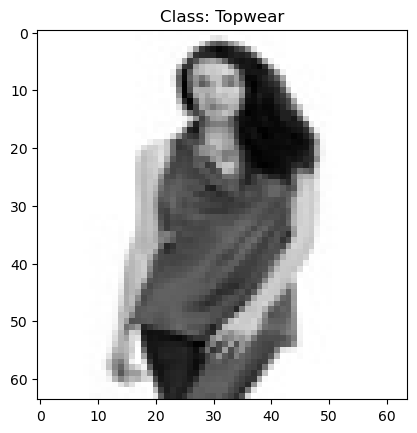

Количество изображений в тренировочной выборке: 29572
Количество изображений в тестовой выборке: 7393


In [73]:
# 1. Скачиваем датасет
path = kagglehub.dataset_download("paramaggarwal/fashion-product-images-small")
print("Path to dataset files:", path)

# 2. Загружаем метаданные
meta = pd.read_csv(os.path.join(path, "styles.csv"), on_bad_lines='skip')
print(meta.head())

# 3. Оставляем только строки с нужными полями и существующими файлами
meta = meta.dropna(subset=['subCategory', 'id'])
meta['image_path'] = meta['id'].astype(str) + ".jpg"
meta = meta[meta['image_path'].apply(lambda x: os.path.isfile(os.path.join(path, "images", x)))]

# 4. Выбираем 10 самых популярных subCategory
top10 = meta['subCategory'].value_counts().index[:10]
meta = meta[meta['subCategory'].isin(top10)]
label2idx = {name: idx for idx, name in enumerate(top10)}
meta['label'] = meta['subCategory'].map(label2idx)

# 5. Класс Dataset
class FashionProductDataset(Dataset):
    def __init__(self, meta, img_dir, transform=None):
        self.meta = meta.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.meta)

    def __getitem__(self, idx):
        img_name = os.path.join(self.img_dir, "images", self.meta.loc[idx, "image_path"])
        image = Image.open(img_name).convert("L").resize((64,64))
        label = int(self.meta.loc[idx, "label"])
        if self.transform:
            image = self.transform(image)
        else:
            image = torchvision.transforms.ToTensor()(image)
        return image, label

# 6. Делим на train/test
train_meta, test_meta = train_test_split(meta, test_size=0.2, stratify=meta['label'], random_state=42)

train_dataset = FashionProductDataset(train_meta, path)
test_dataset = FashionProductDataset(test_meta, path)

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=1, shuffle=True)

# 7. Для отображения названий классов
class_names = {idx: name for name, idx in label2idx.items()}
img, label = train_dataset[20]
plt.imshow(img.squeeze(), cmap='gray')
plt.title(f"Class: {class_names[label]}")
plt.show()

print(f"Количество изображений в тренировочной выборке: {len(train_dataset)}")
print(f"Количество изображений в тестовой выборке: {len(test_dataset)}")

In [74]:
top10 = meta['subCategory'].value_counts().index[:10]
label2idx = {name: idx for idx, name in enumerate(top10)}
meta['label'] = meta['subCategory'].map(label2idx)
print("Label mapping:", label2idx)

Label mapping: {'Topwear': 0, 'Shoes': 1, 'Bags': 2, 'Bottomwear': 3, 'Watches': 4, 'Innerwear': 5, 'Jewellery': 6, 'Eyewear': 7, 'Fragrance': 8, 'Sandal': 9}


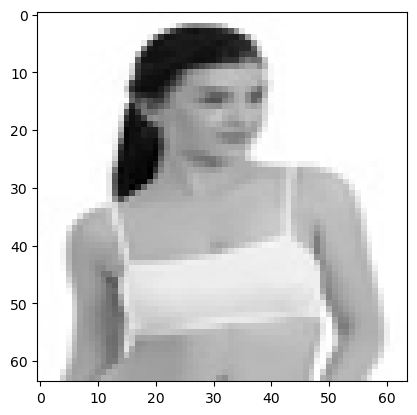

In [75]:
plt.imshow(train_dataset[0][0].reshape(64, 64), cmap='gray')#черно-белое изображение

In [76]:
pd.set_option('display.max_columns', 28)
pd.DataFrame(train_dataset[0][0].reshape(64, 64))#изображение в виде матрицы

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,...,50,51,52,53,54,55,56,57,58,59,60,61,62,63
0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000
1,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000
2,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000
3,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000
4,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,0.996078,1.000000,0.992157,0.996078,1.000000,0.890196,0.709804,0.639216,0.650980,0.639216,0.600000,0.549020,0.482353,0.462745,...,0.882353,0.615686,0.627451,0.701961,0.717647,0.725490,0.729412,0.721569,0.745098,0.858824,1.000000,1.000000,1.0,1.000000
60,0.996078,0.996078,0.992157,0.996078,1.000000,0.839216,0.670588,0.639216,0.650980,0.639216,0.611765,0.552941,0.486275,0.498039,...,0.725490,0.603922,0.662745,0.713726,0.733333,0.725490,0.729412,0.725490,0.788235,0.956863,1.000000,1.000000,1.0,1.000000
61,1.000000,0.996078,0.992157,0.996078,0.988235,0.776471,0.647059,0.647059,0.658824,0.647059,0.596078,0.533333,0.537255,0.643137,...,0.631373,0.643137,0.694118,0.717647,0.733333,0.725490,0.713726,0.752941,0.890196,1.000000,1.000000,0.996078,1.0,1.000000
62,1.000000,0.992157,1.000000,1.000000,0.909804,0.721569,0.643137,0.654902,0.662745,0.627451,0.572549,0.584314,0.674510,0.690196,...,0.607843,0.674510,0.721569,0.733333,0.729412,0.721569,0.725490,0.831373,0.984314,0.996078,0.996078,1.000000,1.0,1.000000


In [ ]:
tens_1 = torch.Tensor([[1]]*batch_size)

class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()

        self.conv2 = nn.Conv2d(1, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2, 2) 

        self.conv3 = nn.Conv2d(64, 1, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(1)
        self.pool3 = nn.MaxPool2d(2, 2) 

        self.adapt_pool = nn.AdaptiveAvgPool2d((16, 16)) 

        self.dropout = nn.Dropout(0.3)
        self.fc1 = nn.Linear(16 * 16, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool2(x)
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.pool3(x)
        x = self.adapt_pool(x)  
        x = x.view(x.size(0), -1) 
        x = self.dropout(x)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)  
        return x

In [78]:
model = SimpleNN()
summary(model, (1, 64, 64), batch_size, device = device)
print(model)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [700, 64, 64, 64]             640
       BatchNorm2d-2          [700, 64, 64, 64]             128
         MaxPool2d-3          [700, 64, 32, 32]               0
            Conv2d-4           [700, 1, 32, 32]             577
       BatchNorm2d-5           [700, 1, 32, 32]               2
         MaxPool2d-6           [700, 1, 16, 16]               0
 AdaptiveAvgPool2d-7           [700, 1, 16, 16]               0
            Linear-8                  [700, 10]           2,570
Total params: 3,917
Trainable params: 3,917
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 10.94
Forward/backward pass size (MB): 3163.73
Params size (MB): 0.01
Estimated Total Size (MB): 3174.68
----------------------------------------------------------------
SimpleNN(
  (conv2): Conv2d(1, 64, kern

In [79]:
optimizer = torch.optim.Adam(model.parameters(), lr=initial_lr)
loss_fn = nn.CrossEntropyLoss()

In [80]:
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.train()
    train_loss, correct = 0, 0
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device).float(), y.to(device)

        # Compute prediction error
        #print(X, data_prep(X))
        pred = model(X)
        loss = loss_fn(pred, y)

        train_loss += loss_fn(pred, y).item()
        correct += (pred.argmax(1) == y).type(torch.float).sum().item()

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

    if batch % 100 == 0:
        loss, current = loss.item(), (batch + 1) * len(X)
        print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")
    
    train_loss /= num_batches
    correct /= size

    return correct, train_loss

def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device).float(), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

    return correct, test_loss

In [81]:
history = {
    'train_loss':[],
    'train_accuracy':[],
    'val_loss':[],
    'val_accuracy':[],
    'test_loss':[],
    'test_accuracy':[]
}

for t in range(epochs):
    running_loss = 0.0
    correct = 0
    total = 0
    print(f"Epoch {t+1}\n-------------------------------")
    #if(t % 2 == 0):
    #    initial_lr /= 2
    #    optimizer = torch.optim.Adam(model.parameters(), lr=initial_lr)
    acc, loss = train(train_dataloader, model, loss_fn, optimizer)
    history['train_accuracy'].append(acc)
    history['train_loss'].append(loss)
    acc, loss = test(test_dataloader, model, loss_fn)
    history['val_accuracy'].append(acc)
    history['val_loss'].append(loss)
print("Done!")

Epoch 1
-------------------------------
Test Error: 
 Accuracy: 48.7%, Avg loss: 1.974317 

Epoch 2
-------------------------------
Test Error: 
 Accuracy: 58.3%, Avg loss: 1.624897 

Epoch 3
-------------------------------
Test Error: 
 Accuracy: 60.7%, Avg loss: 1.452187 

Epoch 4
-------------------------------
Test Error: 
 Accuracy: 66.1%, Avg loss: 1.134471 

Epoch 5
-------------------------------
Test Error: 
 Accuracy: 70.6%, Avg loss: 0.996146 

Epoch 6
-------------------------------
Test Error: 
 Accuracy: 73.6%, Avg loss: 0.890647 

Epoch 7
-------------------------------
Test Error: 
 Accuracy: 75.7%, Avg loss: 0.817867 

Epoch 8
-------------------------------
Test Error: 
 Accuracy: 78.0%, Avg loss: 0.748346 

Epoch 9
-------------------------------
Test Error: 
 Accuracy: 80.0%, Avg loss: 0.694532 

Epoch 10
-------------------------------
Test Error: 
 Accuracy: 81.4%, Avg loss: 0.643849 

Epoch 11
-------------------------------
Test Error: 
 Accuracy: 82.9%, Avg los

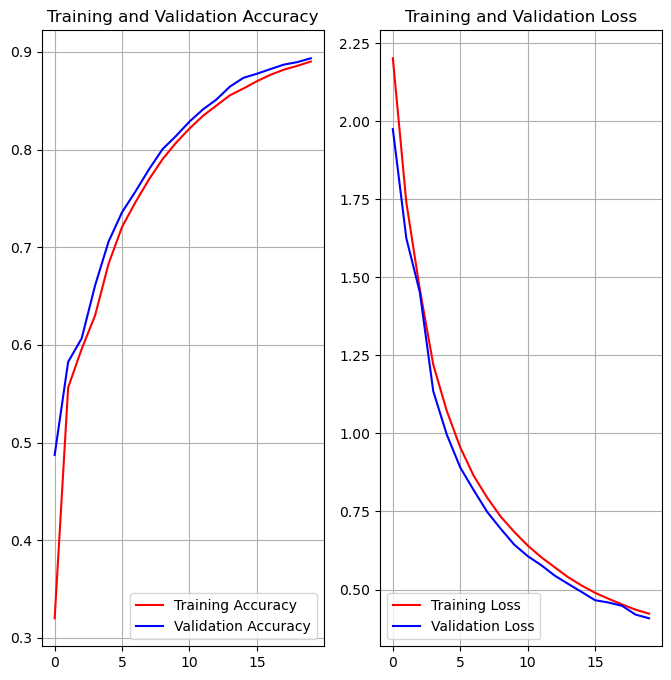

In [82]:
epochs_range = range(epochs)
plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['train_accuracy'], label='Training Accuracy', color='red')
plt.plot(epochs_range, history['val_accuracy'], label='Validation Accuracy', color='blue')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history['train_loss'], label='Training Loss', color='red')
plt.plot(epochs_range, history['val_loss'], label='Validation Loss', color='blue')
plt.legend(loc='lower left')
plt.title('Training and Validation Loss')
plt.grid()
plt.show()

In [83]:
model.eval()
test_dataloader
predictions = torch.LongTensor().to(device)
cmt = torch.zeros(10, 10, dtype=torch.int32)#Матрица ошибок
with torch.no_grad():
    for X, y in test_dataloader:
        X, y = X.to(device).float(), y.to(device)
        preds = model(X.to(device))
        predictions = preds.argmax(dim=1)
        cmt[y, predictions] += 1
    

In [84]:
pd.set_option('display.max_columns', 10)
df_cmt = pd.DataFrame(
    cmt.numpy(),
    index=[f"True: {class_names[i]}" for i in range(10)],
    columns=[f"Pred: {class_names[i]}" for i in range(10)]
)
df_cmt

,Pred: Topwear,Pred: Shoes,Pred: Bags,Pred: Bottomwear,Pred: Watches,Pred: Innerwear,Pred: Jewellery,Pred: Eyewear,Pred: Fragrance,Pred: Sandal
True: Topwear,3003,4,18,12,6,17,12,0,8,0
True: Shoes,3,1445,4,0,1,13,2,1,0,0
True: Bags,33,6,542,0,7,9,2,0,12,0
True: Bottomwear,54,5,23,432,3,7,4,1,9,0
True: Watches,36,0,3,4,458,1,4,0,2,0
True: Innerwear,88,7,7,2,0,256,2,0,0,0
True: Jewellery,18,18,2,33,4,4,120,0,17,0
True: Eyewear,0,1,0,0,0,0,0,214,0,0
True: Fragrance,28,0,20,8,3,3,14,0,126,0
True: Sandal,0,183,0,0,0,0,0,0,0,9
